In [ ]:
# Cell 1: Import libraries

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 2: Download dataset

!pip -q install gdown

import gdown

file_id = "1219EeGE1XTJVXYaulynJSa3BXGsbNCLx"
zip_file = "/content/chest_xray_dataset.zip"

gdown.download(
    id=file_id,
    output=zip_file,
    quiet=False
)

print("Download completed!")

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=090db278-181b-49ab-85ac-18a85871252a
To: /content/chest_xray_dataset.zip
100%|██████████| 1.23G/1.23G [00:13<00:00, 94.1MB/s]

Download completed!


In [ ]:
# Cell 3: Extract the dataset

extract_folder = "/content/xray_data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
# Cell 4: Check dataset folders

for root, folders, files in os.walk(extract_folder):
    if {"train", "test", "val"}.issubset(set(folders)):
        print("Dataset folder found:")
        print(root)
        break

Dataset folder found:
/content/xray_data


In [ ]:
# Cell 5: Set dataset paths

DATA_DIR = extract_folder

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
VAL_DIR = os.path.join(DATA_DIR, "val")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/xray_data/train
Validation: /content/xray_data/val
Test: /content/xray_data/test


In [ ]:
# Cell 6: Count images in each class

image_types = (".jpg", ".jpeg", ".png")

for split_name, split_path in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:
    print(f"\n{split_name} set")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = sum(
                file.lower().endswith(image_types)
                for file in os.listdir(class_path)
            )
            print(f"{class_name}: {count}")


Train set
NORMAL: 1341
PNEUMONIA: 3875

Validation set
NORMAL: 8
PNEUMONIA: 8

Test set
NORMAL: 234
PNEUMONIA: 390


In [ ]:
# Cell 7: Load X-ray images

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=True,
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_data.class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


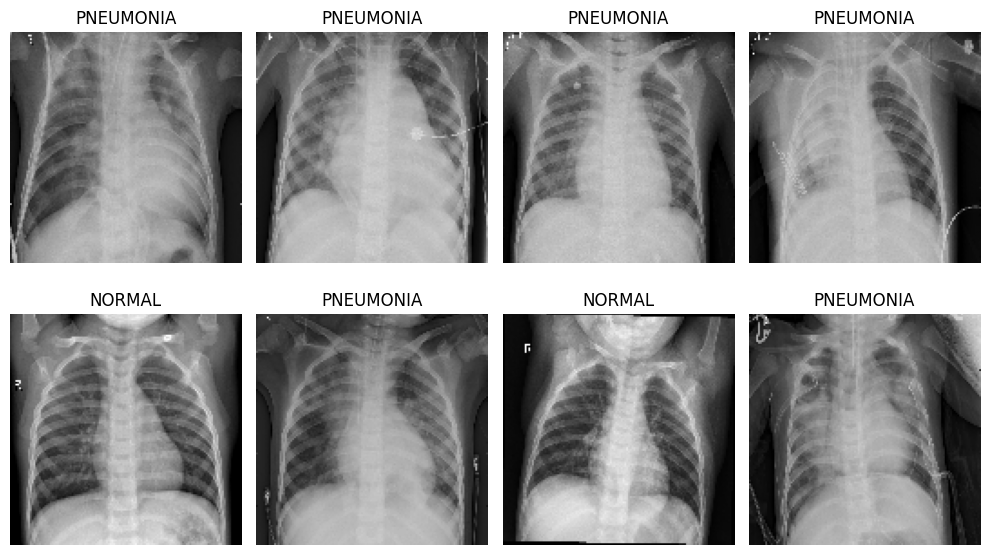

In [ ]:
# Cell 8: Display sample X-ray images

plt.figure(figsize=(10, 6))

for images, labels in train_data.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_data.class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Improve dataset performance

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Dataset preparation completed!")

Dataset preparation completed!


In [ ]:
# Cell 10: Calculate class weights

normal_count = 1341
pneumonia_count = 3875
total_images = normal_count + pneumonia_count

class_weights = {
    0: total_images / (2 * normal_count),
    1: total_images / (2 * pneumonia_count)
}

print("Class weights:")
print("NORMAL:", round(class_weights[0], 3))
print("PNEUMONIA:", round(class_weights[1], 3))

Class weights:
NORMAL: 1.945
PNEUMONIA: 0.673


In [ ]:
# Cell 11: Build the CNN model

model = models.Sequential([

    layers.Input(shape=(128, 128, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),

    # Normalize pixel values
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convolution Block 4
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Convert feature maps into a compact representation
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,633 (1.61 MB)

 Trainable params: 421,249 (1.61 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Cell 12: Compile the CNN

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Cell 13: Training callbacks

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

save_best = tf.keras.callbacks.ModelCheckpoint(
    "/content/best_xray_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks are ready!")

Callbacks are ready!


In [ ]:
# Cell 14: Train the CNN

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, save_best]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.8399 - auc: 0.9201 - loss: 0.3545 - val_accuracy: 0.5000 - val_auc: 0.7734 - val_loss: 2.0509 - learning_rate: 3.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - accuracy: 0.8951 - auc: 0.9652 - loss: 0.2360 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 4.5284 - learning_rate: 3.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 147ms/step - accuracy: 0.9170 - auc: 0.9750 - loss: 0.1984 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 4.7061 - learning_rate: 3.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.9398 - auc: 0.9853 - loss: 0.1492 - val_accuracy: 0.5625 - val_auc: 0.8516 - val_loss: 1.0819 - learning_rate: 1.5000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.9448 - auc: 0.9864 - loss: 0.1443 - val_accuracy: 0.5000 - val_auc: 0.7500 - val_loss: 3.1274 - learning_rate: 1.5000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 1

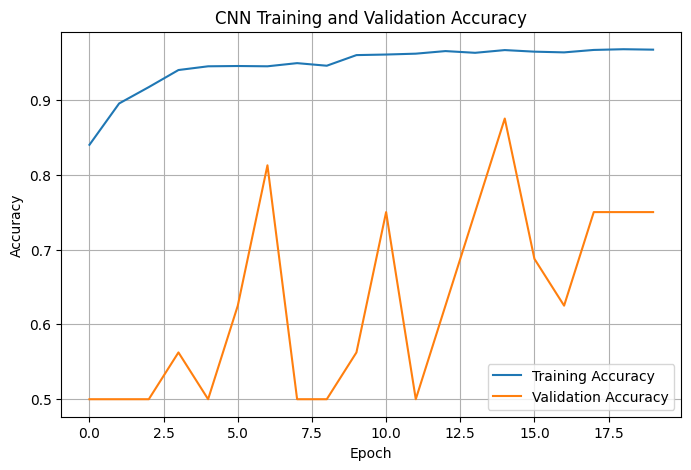

In [ ]:
# Cell 15: Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

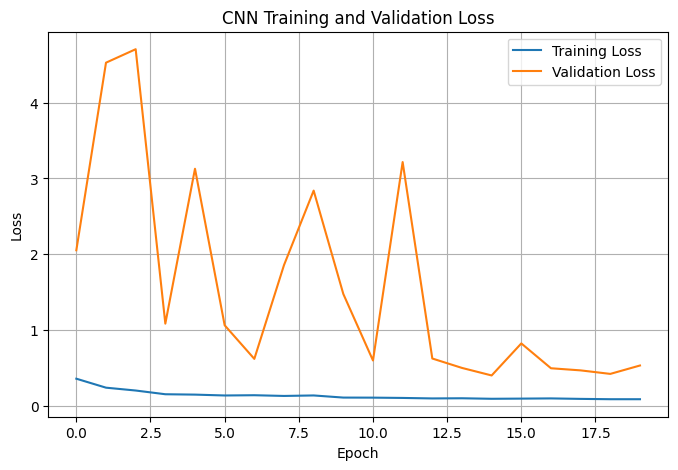

In [ ]:
# Cell 16: Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Cell 17: Evaluate the model on test data

test_loss, test_accuracy, test_auc = model.evaluate(test_data, verbose=1)

print("\nTest Results")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test AUC:", round(test_auc, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.8814 - auc: 0.9394 - loss: 0.3311

Test Results
Test Loss: 0.3311
Test Accuracy: 88.14 %
Test AUC: 0.9394


In [ ]:
# Cell 18: Generate predictions and classification report

class_names = ["NORMAL", "PNEUMONIA"]

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().ravel().astype(int))
    y_pred.extend((predictions.ravel() >= 0.5).astype(int))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

      NORMAL     0.8704    0.8034    0.8356       234
   PNEUMONIA     0.8873    0.9282    0.9073       390

    accuracy                         0.8814       624
   macro avg     0.8788    0.8658    0.8714       624
weighted avg     0.8809    0.8814    0.8804       624



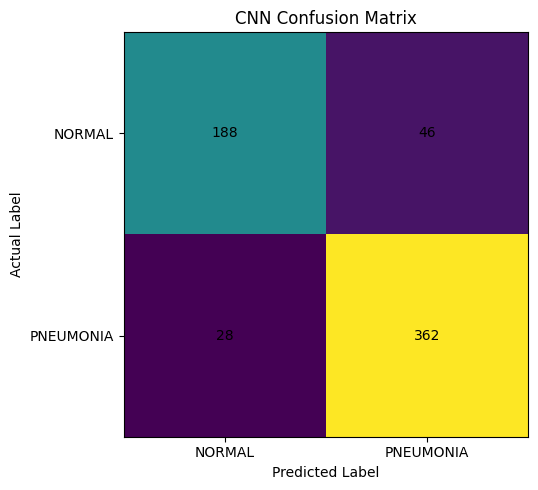

Confusion Matrix:
[[188  46]
 [ 28 362]]


In [ ]:
# Cell 19: Confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

for row in range(2):
    for col in range(2):
        plt.text(col, row, cm[row, col],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [ ]:
# Cell 20: Save the trained CNN model

model.save("/content/chest_xray_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


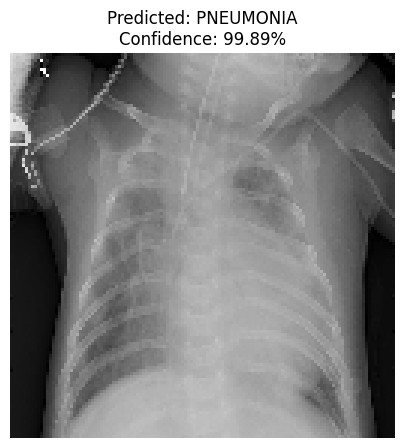

Actual class: PNEUMONIA
Predicted class: PNEUMONIA


In [ ]:
# Cell 21: Predict a single X-ray

sample_class = "PNEUMONIA"
sample_folder = os.path.join(TEST_DIR, sample_class)

sample_file = next(
    file for file in os.listdir(sample_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
)

sample_path = os.path.join(sample_folder, sample_file)

image = tf.keras.utils.load_img(
    sample_path,
    color_mode="grayscale",
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

probability = model.predict(image_array, verbose=0)[0][0]

if probability >= 0.5:
    prediction = "PNEUMONIA"
    confidence = probability
else:
    prediction = "NORMAL"
    confidence = 1 - probability

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title(f"Predicted: {prediction}\nConfidence: {confidence * 100:.2f}%")
plt.axis("off")
plt.show()

print("Actual class:", sample_class)
print("Predicted class:", prediction)